# EV Charging Load Prediction - Exploratory Data Analysis

This notebook performs comprehensive EDA on the training data for the EV charging station load prediction competition.

## Contents
1. Data Loading & Basic Info
2. Time Series Analysis
3. Periodicity Analysis (Daily/Weekly/Monthly)
4. Feature Correlation
5. External Data Integration
6. Visualization Summary

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Try to import seaborn for enhanced visualizations
try:
    import seaborn as sns
    HAS_SEABORN = True
    plt.style.use('seaborn-v0_8-whitegrid')
except ImportError:
    HAS_SEABORN = False
    plt.style.use('ggplot')
    print("Note: seaborn not installed, using matplotlib fallback for some plots")

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_RAW}")

Project root: /Users/z/基于多源数据融合的电动汽车充电协同优化挑战
Data directory: /Users/z/基于多源数据融合的电动汽车充电协同优化挑战/data/raw


---
## 1. Data Loading & Basic Info

In [28]:
# Load training data - skip first row (Chinese headers), use second row as headers
train_df = pd.read_csv(
    DATA_RAW / 'A榜-充电站充电负荷训练数据.csv',
    encoding='gbk',
    skiprows=1  # Skip Chinese header row
)

print("=== Training Data Shape ===")
print(f"Rows: {train_df.shape[0]:,}, Columns: {train_df.shape[1]}")
print()
print("=== Column Names ===")
print(train_df.columns.tolist())
print()
print("=== Data Types ===")
print(train_df.dtypes)
print()
print("=== First 5 Rows ===")
train_df.head()

=== Training Data Shape ===
Rows: 29,280, Columns: 14

=== Column Names ===
['NAME', 'SENID', 'TIME', 'V', 'AVGV', 'MAXV', 'MAXT', 'MINV', 'MINT', 'S', 'AVGS', 'MAXS', 'MINS', 'SPAN']

=== Data Types ===
NAME         str
SENID        str
TIME         str
V        float64
AVGV     float64
MAXV     float64
MAXT         str
MINV     float64
MINT         str
S        float64
AVGS     float64
MAXS     float64
MINS     float64
SPAN     float64
dtype: object

=== First 5 Rows ===


,NAME,SENID,TIME,V,AVGV,MAXV,MAXT,MINV,MINT,S,AVGS,MAXS,MINS,SPAN
0,电动汽车充电站,1001-1012,2024/1/1 0:00,6.93,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.241,0.24,0.26,0.223,0.037
1,电动汽车充电站,1001-1012,2024/1/1 0:15,7.48,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.251,0.24,0.26,0.223,0.037
2,电动汽车充电站,1001-1012,2024/1/1 0:30,8.22,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.244,0.24,0.26,0.223,0.037
3,电动汽车充电站,1001-1012,2024/1/1 0:45,8.90,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.244,0.24,0.26,0.223,0.037
4,电动汽车充电站,1001-1012,2024/1/1 1:00,9.05,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.253,0.24,0.26,0.223,0.037


In [29]:
# Parse TIME column as datetime
train_df['TIME'] = pd.to_datetime(train_df['TIME'])

print("=== Time Range ===")
print(f"Start: {train_df['TIME'].min()}")
print(f"End: {train_df['TIME'].max()}")
print(f"Duration: {(train_df['TIME'].max() - train_df['TIME'].min()).days + 1} days")

=== Time Range ===
Start: 2024-01-01 00:00:00
End: 2024-10-31 23:45:00
Duration: 305 days


In [30]:
# Check for missing values
print("=== Missing Values ===")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")
print()
print("=== Basic Statistics ===")
train_df.describe()

=== Missing Values ===
No missing values!

=== Basic Statistics ===


,TIME,V,AVGV,MAXV,MINV,S,AVGS,MAXS,MINS,SPAN
count,29280,29280.000000,29280.000000,29280.000000,29280.000000,29280.000000,29280.000000,29280.000000,29280.000000,29280.000000
mean,2024-06-01 11:52:29.999999,5.327657,5.327639,8.994164,1.819770,0.240687,0.240685,0.256216,0.224656,0.031561
min,2024-01-01 00:00:00,1.210000,4.680000,8.360000,1.210000,0.216000,0.237000,0.250000,0.216000,0.023000
25%,2024-03-17 05:56:15,3.450000,4.720000,8.620000,1.570000,0.236000,0.240000,0.254000,0.223000,0.029000
50%,2024-06-01 11:52:30,5.400000,5.180000,8.800000,1.690000,0.241000,0.240000,0.256000,0.225000,0.032000
75%,2024-08-16 17:48:45,7.092500,6.140000,9.440000,2.170000,0.245000,0.242000,0.258000,0.227000,0.034000
max,2024-10-31 23:45:00,9.850000,6.800000,9.850000,2.670000,0.264000,0.245000,0.264000,0.231000,0.042000
std,NaN,2.133995,0.716235,0.426652,0.357752,0.006610,0.001568,0.002544,0.002860,0.003710


In [31]:
# Check sampling interval consistency
time_diffs = train_df['TIME'].diff().dropna()
unique_intervals = time_diffs.unique()

print("=== Sampling Intervals ===")
print(f"Expected interval: 15 minutes")
print(f"Unique intervals found: {len(unique_intervals)}")
if len(unique_intervals) <= 5:
    for interval in unique_intervals[:5]:
        count = (time_diffs == interval).sum()
        print(f"  {interval}: {count} occurrences")

=== Sampling Intervals ===
Expected interval: 15 minutes
Unique intervals found: 1
  0 days 00:15:00: 29279 occurrences


---
## 2. Time Series Analysis

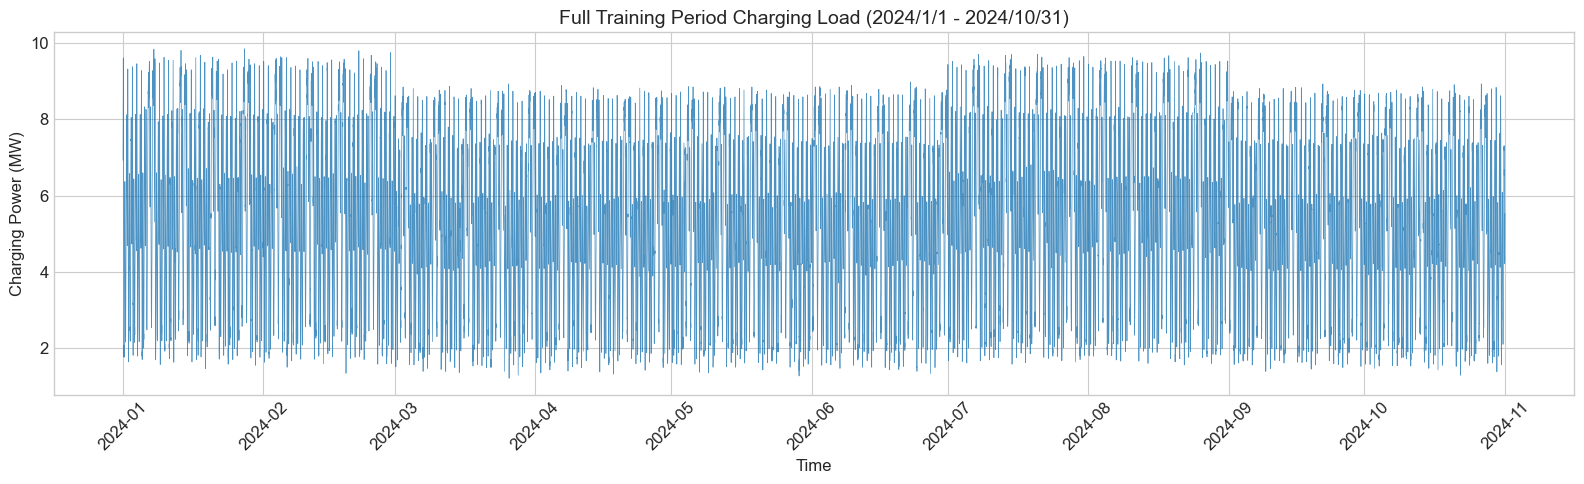

In [32]:
# Full time series plot
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train_df['TIME'], train_df['V'], linewidth=0.5, alpha=0.8)
ax.set_xlabel('Time')
ax.set_ylabel('Charging Power (MW)')
ax.set_title('Full Training Period Charging Load (2024/1/1 - 2024/10/31)')

# Add month markers
monthly_ticks = pd.date_range(start='2024-01-01', end='2024-11-01', freq='MS')
ax.set_xticks(monthly_ticks)
ax.set_xticklabels([t.strftime('%Y-%m') for t in monthly_ticks], rotation=45)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_full_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

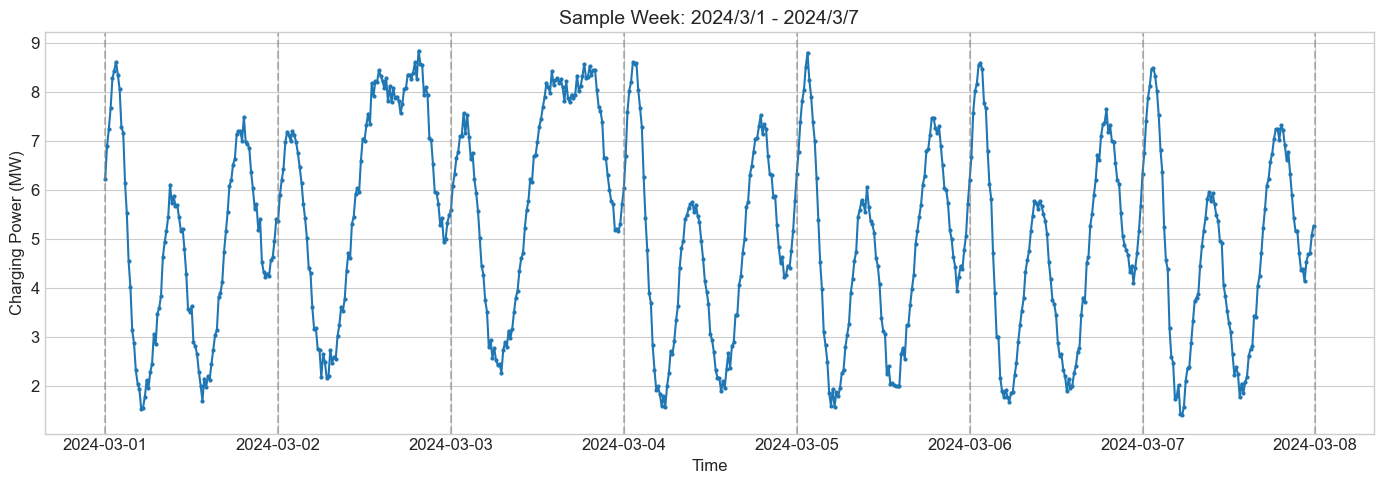

In [33]:
# Zoom into a sample week
sample_week = train_df[(train_df['TIME'] >= '2024-03-01') & (train_df['TIME'] < '2024-03-08')]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sample_week['TIME'], sample_week['V'], linewidth=1.5, marker='o', markersize=2)
ax.set_xlabel('Time')
ax.set_ylabel('Charging Power (MW)')
ax.set_title('Sample Week: 2024/3/1 - 2024/3/7')

# Add day markers
day_ticks = pd.date_range(start='2024-03-01', end='2024-03-08', freq='D')
for day in day_ticks:
    ax.axvline(x=day, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_sample_week.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Periodicity Analysis

In [34]:
# Extract time features
train_df['hour'] = train_df['TIME'].dt.hour
train_df['minute'] = train_df['TIME'].dt.minute
train_df['dayofweek'] = train_df['TIME'].dt.dayofweek  # 0=Monday, 6=Sunday
train_df['month'] = train_df['TIME'].dt.month
train_df['day'] = train_df['TIME'].dt.day
train_df['is_weekend'] = train_df['dayofweek'].isin([5, 6])

print("=== Time Features Added ===")
print(train_df[['TIME', 'hour', 'dayofweek', 'month', 'is_weekend']].head(10))

=== Time Features Added ===
                 TIME  hour  dayofweek  month  is_weekend
0 2024-01-01 00:00:00     0          0      1       False
1 2024-01-01 00:15:00     0          0      1       False
2 2024-01-01 00:30:00     0          0      1       False
3 2024-01-01 00:45:00     0          0      1       False
4 2024-01-01 01:00:00     1          0      1       False
5 2024-01-01 01:15:00     1          0      1       False
6 2024-01-01 01:30:00     1          0      1       False
7 2024-01-01 01:45:00     1          0      1       False
8 2024-01-01 02:00:00     2          0      1       False
9 2024-01-01 02:15:00     2          0      1       False


### 3.1 Daily Pattern (Hourly Average)

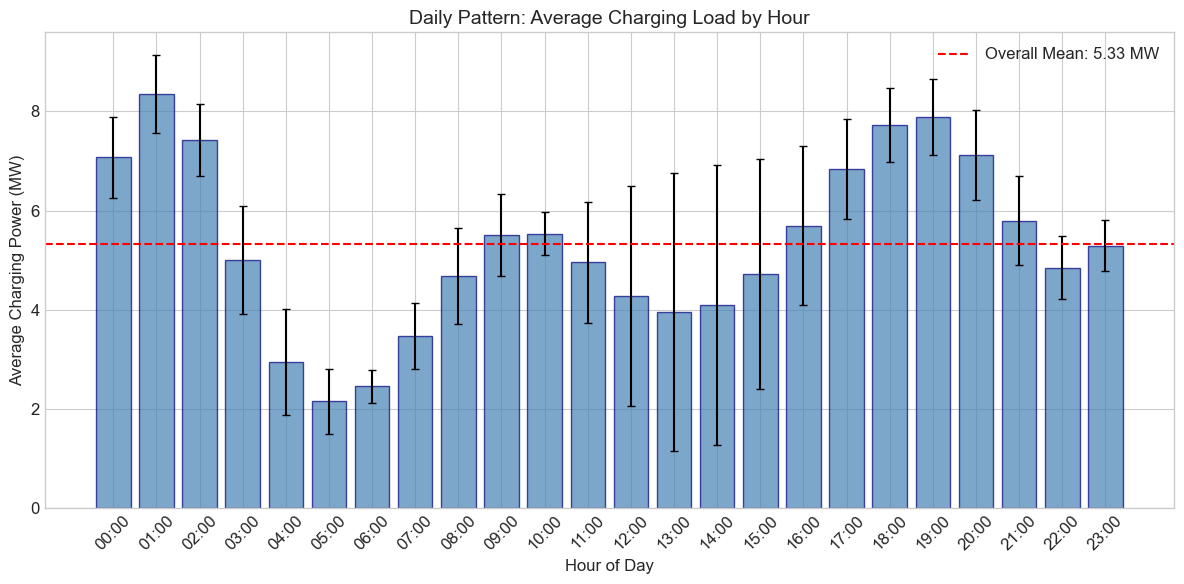

Peak hour: 01:00 (avg: 8.35 MW)
Min hour: 05:00 (avg: 2.16 MW)


In [35]:
# Hourly average load
hourly_avg = train_df.groupby('hour')['V'].agg(['mean', 'std', 'min', 'max'])

fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart with error bars
bars = ax.bar(hourly_avg.index, hourly_avg['mean'], 
               yerr=hourly_avg['std'], capsize=3, 
               color='steelblue', alpha=0.7, edgecolor='navy')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Charging Power (MW)')
ax.set_title('Daily Pattern: Average Charging Load by Hour')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)

# Highlight peak hours
peak_hour = hourly_avg['mean'].idxmax()
min_hour = hourly_avg['mean'].idxmin()
ax.axhline(y=hourly_avg['mean'].mean(), color='red', linestyle='--', label=f'Overall Mean: {hourly_avg["mean"].mean():.2f} MW')

ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_daily_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak hour: {peak_hour:02d}:00 (avg: {hourly_avg.loc[peak_hour, 'mean']:.2f} MW)")
print(f"Min hour: {min_hour:02d}:00 (avg: {hourly_avg.loc[min_hour, 'mean']:.2f} MW)")

### 3.2 Weekly Pattern (Weekday vs Weekend)

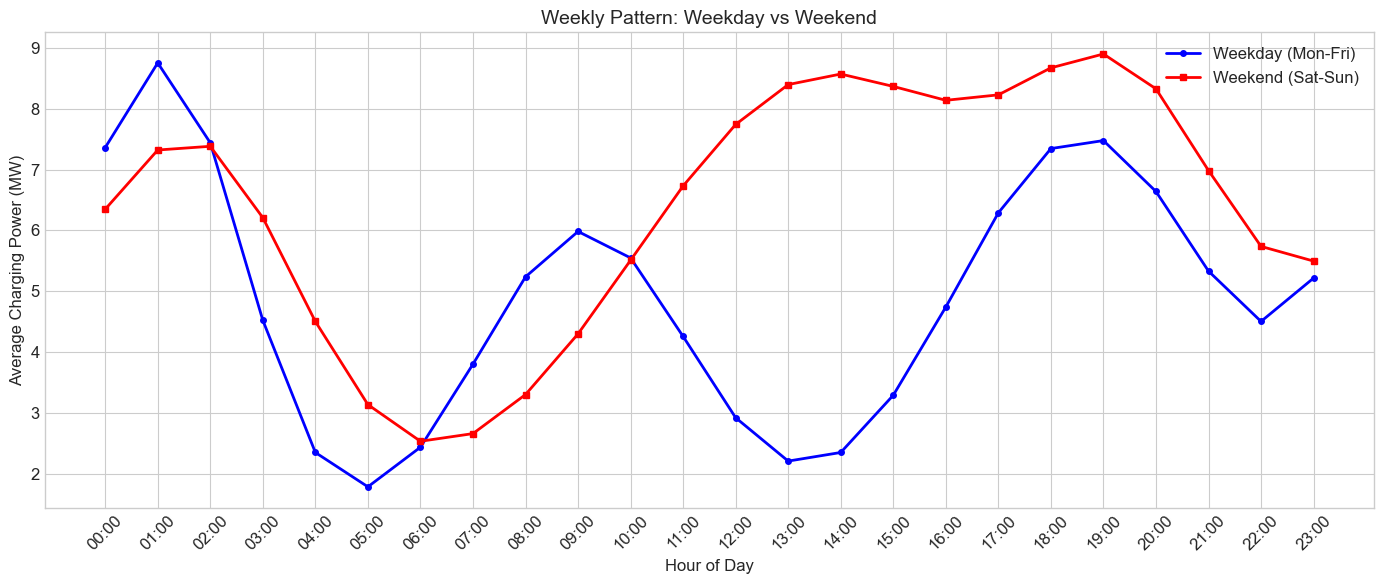

In [36]:
# Weekly pattern
weekly_pattern = train_df.groupby(['dayofweek', 'hour'])['V'].mean().unstack(level=0)
weekly_pattern.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 6))

# Plot weekday average
weekday_avg = weekly_pattern[['Mon', 'Tue', 'Wed', 'Thu', 'Fri']].mean(axis=1)
weekend_avg = weekly_pattern[['Sat', 'Sun']].mean(axis=1)

ax.plot(weekday_avg.index, weekday_avg.values, 'b-', linewidth=2, label='Weekday (Mon-Fri)', marker='o', markersize=4)
ax.plot(weekend_avg.index, weekend_avg.values, 'r-', linewidth=2, label='Weekend (Sat-Sun)', marker='s', markersize=4)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Charging Power (MW)')
ax.set_title('Weekly Pattern: Weekday vs Weekend')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_weekly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

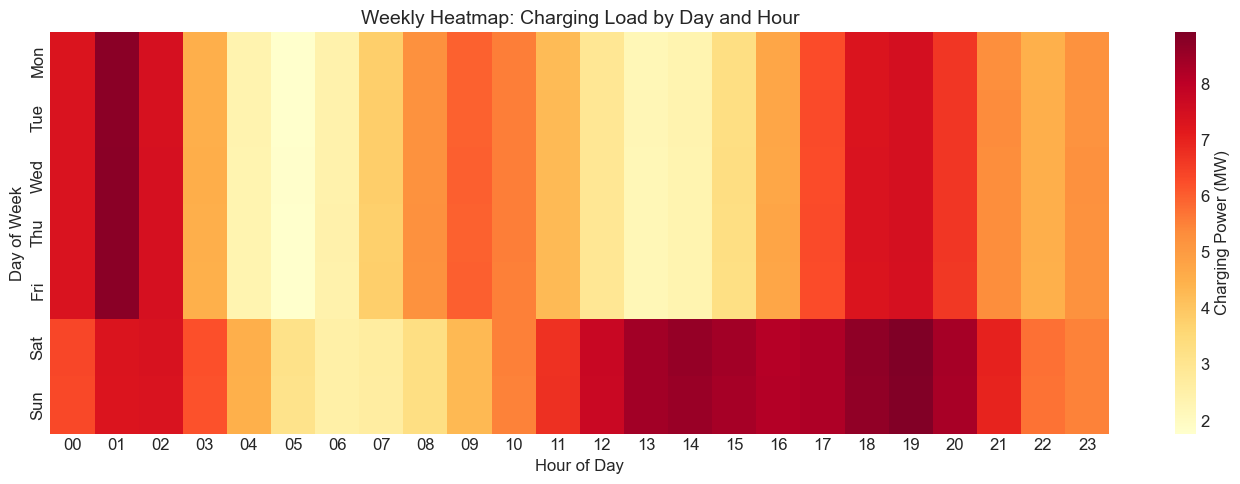

In [37]:
# Heatmap: Day of Week x Hour
fig, ax = plt.subplots(figsize=(14, 5))

heatmap_data = train_df.groupby(['dayofweek', 'hour'])['V'].mean().unstack()
heatmap_data.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

if HAS_SEABORN:
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, 
                xticklabels=[f'{h:02d}' for h in range(24)],
                cbar_kws={'label': 'Charging Power (MW)'})
else:
    # Matplotlib fallback
    im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{h:02d}' for h in range(24)])
    ax.set_yticks(range(7))
    ax.set_yticklabels(heatmap_data.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Charging Power (MW)')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Weekly Heatmap: Charging Load by Day and Hour')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_weekly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Monthly Pattern (Seasonal Trends)

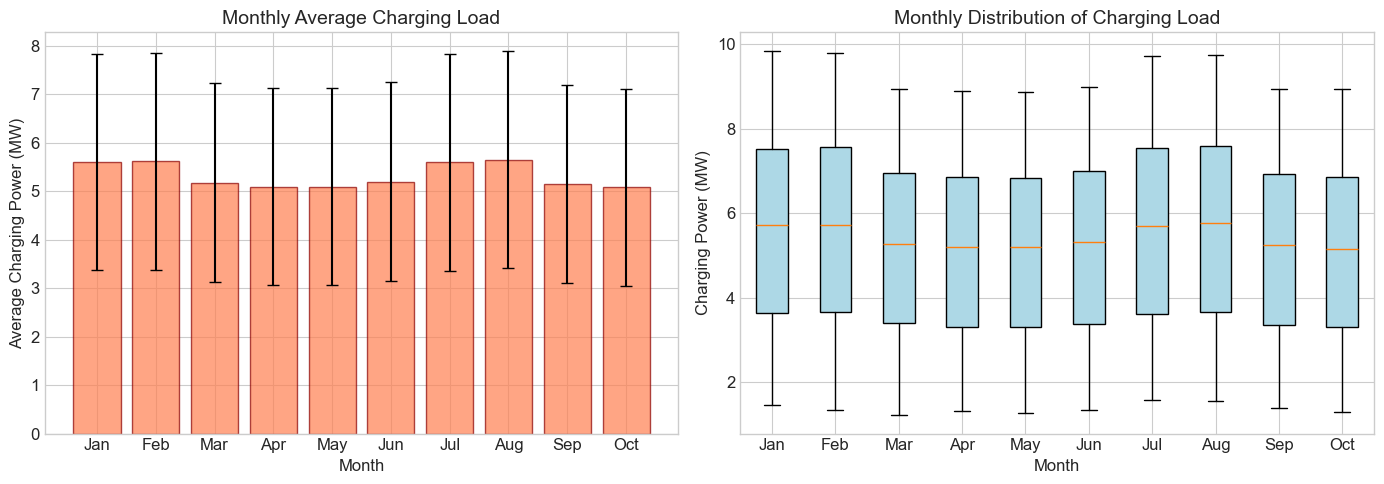

=== Monthly Statistics ===
       mean   std   min   max  count
month                               
1      5.60  2.23  1.46  9.85   2976
2      5.62  2.24  1.34  9.80   2784
3      5.18  2.05  1.21  8.93   2976
4      5.10  2.03  1.32  8.89   2880
5      5.09  2.03  1.27  8.86   2976
6      5.20  2.05  1.33  8.98   2880
7      5.60  2.23  1.58  9.71   2976
8      5.65  2.24  1.56  9.74   2976
9      5.15  2.04  1.39  8.93   2880
10     5.09  2.03  1.29  8.93   2976


In [38]:
# Monthly statistics
monthly_stats = train_df.groupby('month')['V'].agg(['mean', 'std', 'min', 'max', 'count'])
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average with error bars
axes[0].bar(monthly_stats.index, monthly_stats['mean'], 
            yerr=monthly_stats['std'], capsize=4,
            color='coral', alpha=0.7, edgecolor='darkred')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Charging Power (MW)')
axes[0].set_title('Monthly Average Charging Load')
axes[0].set_xticks(range(1, 11))
axes[0].set_xticklabels(month_names)

# Monthly distribution (box plot)
monthly_data = [train_df[train_df['month'] == m]['V'].values for m in range(1, 11)]
bp = axes[1].boxplot(monthly_data, labels=month_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Charging Power (MW)')
axes[1].set_title('Monthly Distribution of Charging Load')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_monthly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Monthly Statistics ===")
print(monthly_stats.round(2))

---
## 4. Feature Correlation

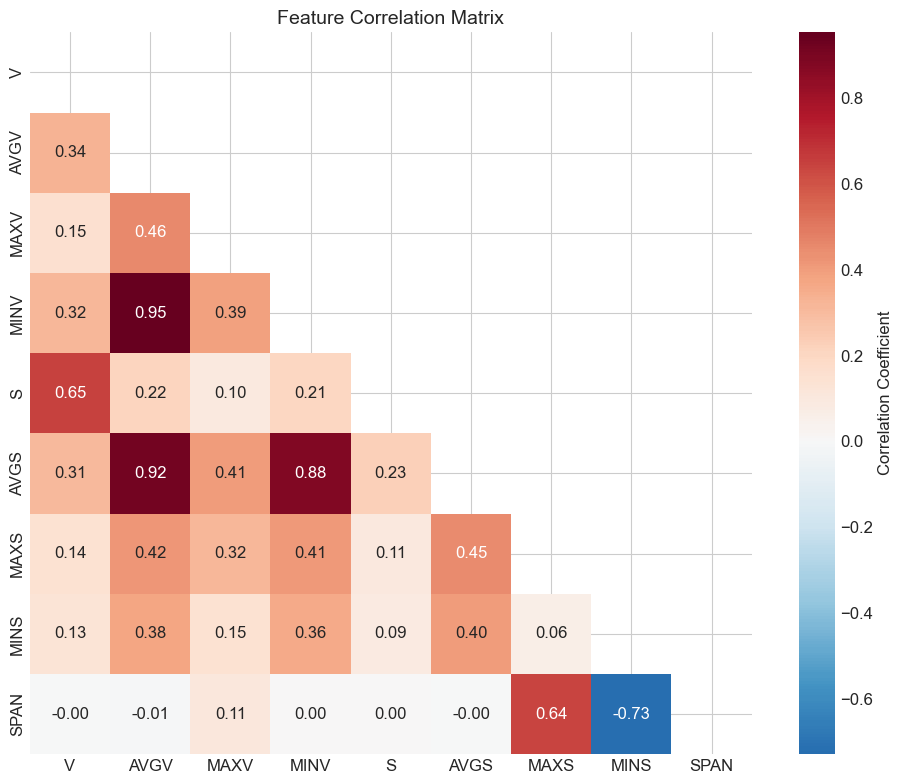

=== Correlations with Target (V) ===
V       1.000000
S       0.650680
AVGV    0.335672
MINV    0.320247
AVGS    0.307687
MAXV    0.153840
MAXS    0.139729
MINS    0.127810
SPAN   -0.002720
Name: V, dtype: float64


In [39]:
# Select numeric columns for correlation
numeric_cols = ['V', 'AVGV', 'MAXV', 'MINV', 'S', 'AVGS', 'MAXS', 'MINS', 'SPAN']
corr_matrix = train_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

if HAS_SEABORN:
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=ax,
                cbar_kws={'label': 'Correlation Coefficient'})
else:
    # Matplotlib fallback - show lower triangle only
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    corr_masked = corr_matrix.mask(mask)
    im = ax.imshow(corr_masked.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
    ax.set_yticklabels(numeric_cols)
    # Add annotations
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            if i > j:  # Lower triangle only
                text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                              ha='center', va='center', color='black', fontsize=9)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation Coefficient')

ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Correlations with Target (V) ===")
print(corr_matrix['V'].sort_values(ascending=False))

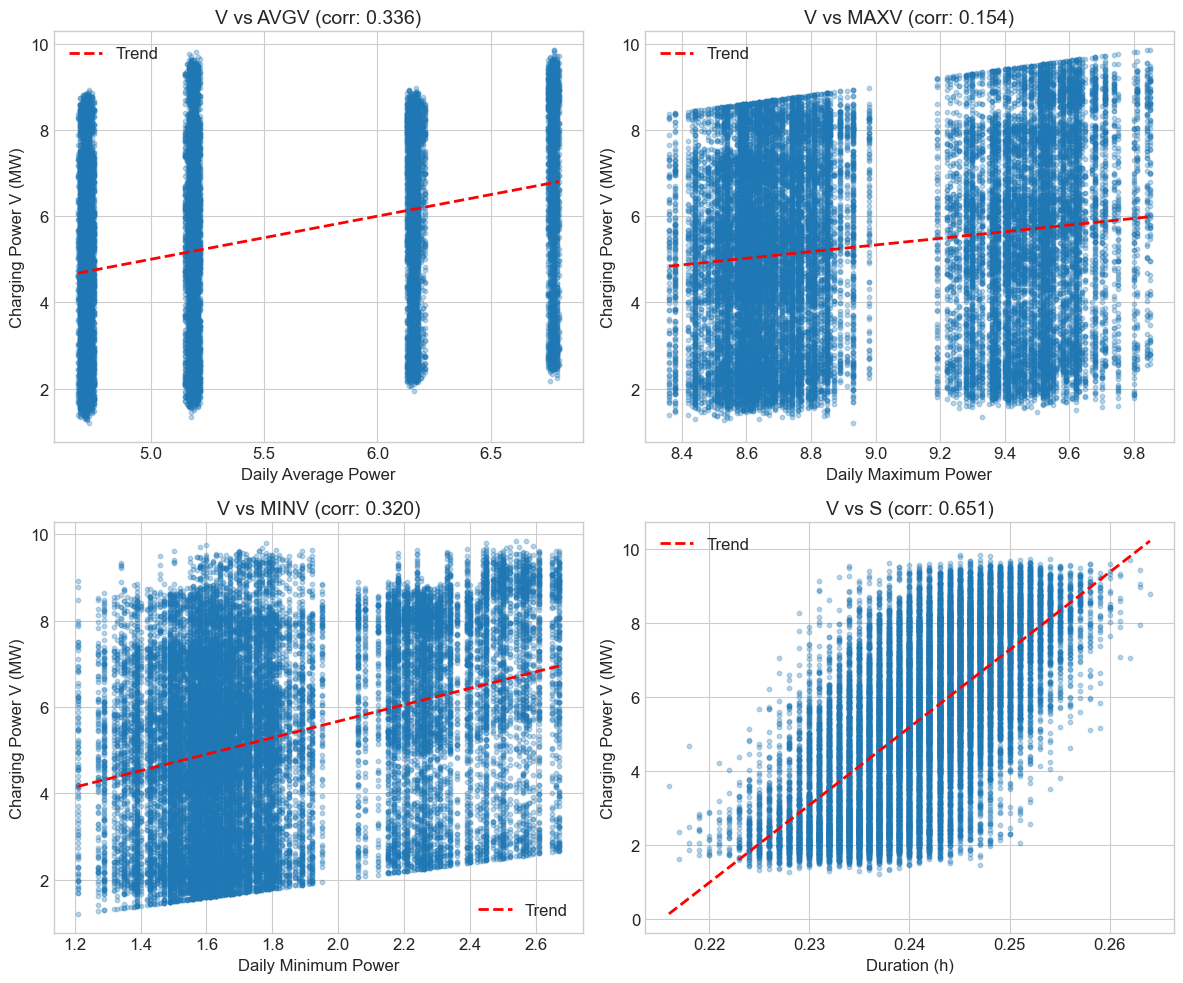

In [40]:
# Scatter plots: V vs key features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = [('AVGV', 'Daily Average Power'),
            ('MAXV', 'Daily Maximum Power'),
            ('MINV', 'Daily Minimum Power'),
            ('S', 'Duration (h)')]

for ax, (feat, label) in zip(axes.flat, features):
    ax.scatter(train_df[feat], train_df['V'], alpha=0.3, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Charging Power V (MW)')
    ax.set_title(f'V vs {feat} (corr: {corr_matrix.loc[feat, "V"]:.3f})')
    
    # Add trend line
    z = np.polyfit(train_df[feat], train_df['V'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(train_df[feat].min(), train_df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_scatter_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. External Data Integration Preview

In [41]:
# Load V2G station prices
v2g_prices = pd.read_csv(DATA_RAW / '附件1-V2G站向电网售电及从电网购电电价.csv', encoding='gbk')
print("=== V2G Station Prices ===")
print(v2g_prices)

=== V2G Station Prices ===
            时段  0:00-6:00  6:00-10:00  10:00-14:00  14:00-18:00  18:00-24:00
0  售电电价(元/kWh)        0.2        0.40         0.35          0.3         0.45
1  购电电价(元/kWh)        0.3        0.75         0.70          0.6         0.80


=== PV Output (Typical Day Profile) ===
Shape: (96, 2)
          时段  光伏(kW)
0  0:00-0:15     0.0
1  0:15-0:30     0.0
2  0:30-0:45     0.0
3  0:45-1:00     0.0
4  1:00-1:15     0.0
5  1:15-1:30     0.0
6  1:30-1:45     0.0
7  1:45-2:00     0.0
8  2:00-2:15     0.0
9  2:15-2:30     0.0


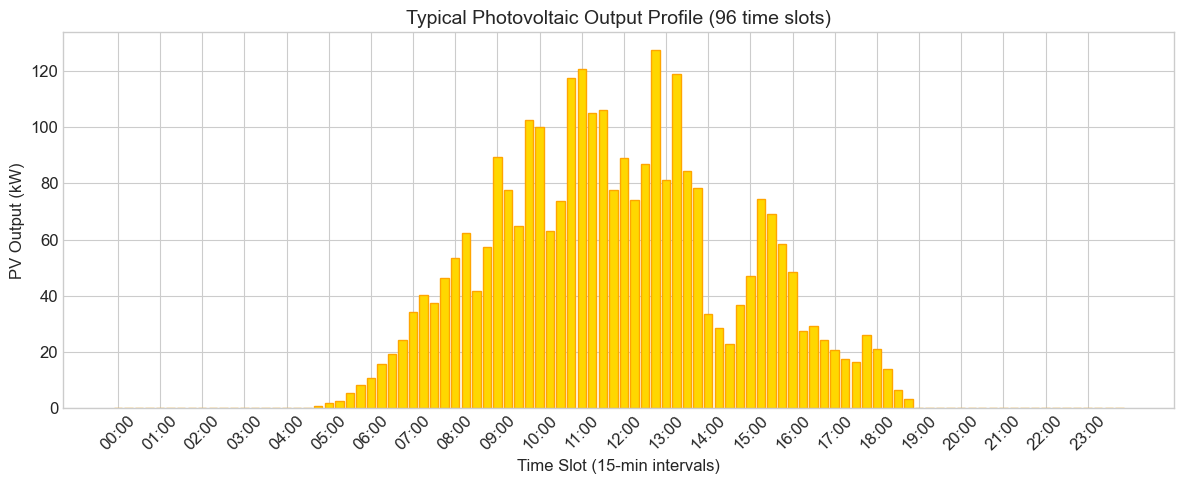

In [42]:
# Load PV output
pv_output = pd.read_excel(DATA_RAW / '附件2-光伏典型出力.xlsx')
print("=== PV Output (Typical Day Profile) ===")
print(f"Shape: {pv_output.shape}")
print(pv_output.head(10))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(pv_output)), pv_output['光伏(kW)'], color='gold', edgecolor='orange')
ax.set_xlabel('Time Slot (15-min intervals)')
ax.set_ylabel('PV Output (kW)')
ax.set_title('Typical Photovoltaic Output Profile (96 time slots)')
ax.set_xticks(range(0, 96, 4))
ax.set_xticklabels([f'{i//4:02d}:{(i%4)*15:02d}' for i in range(0, 96, 4)], rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_pv_output.png', dpi=150, bbox_inches='tight')
plt.show()

=== EV User Charge/Discharge Prices ===
             时段  充电电价(元/kWh)  放电电价(元/kWh)
0     0:00-1:00         0.48         0.48
1     1:00-2:00         0.54         0.54
2     2:00-3:00         0.60         0.60
3     3:00-4:00         0.60         0.60
4     4:00-5:00         0.66         0.67
5     5:00-6:00         0.72         0.73
6     6:00-7:00         0.90         0.90
7     7:00-8:00         0.96         1.08
8     8:00-9:00         1.02         1.20
9    9:00-10:00         1.08         1.50
10  10:00-11:00         1.20         1.80
11  11:00-12:00         1.26         2.10
12  12:00-13:00         1.08         1.62
13  13:00-14:00         0.96         1.26
14  14:00-15:00         0.78         1.02
15  15:00-16:00         0.72         0.90
16  16:00-17:00         0.60         0.60
17  17:00-18:00         0.60         0.60
18  18:00-19:00         0.72         0.90
19  19:00-20:00         0.96         1.32
20  20:00-21:00         1.20         1.50
21  21:00-22:00         0.78        

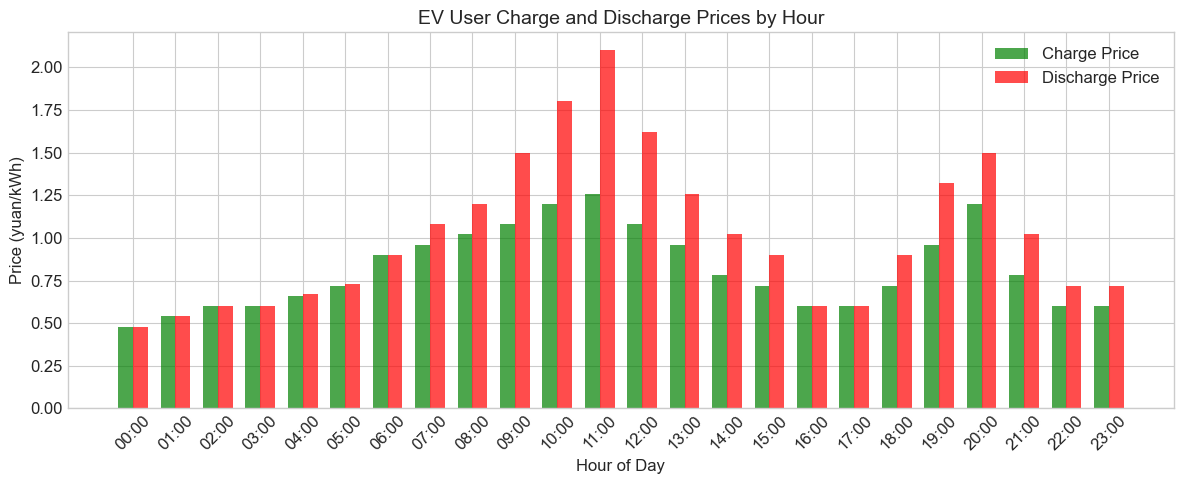

In [43]:
# Load EV user prices
ev_prices = pd.read_csv(DATA_RAW / '附件3 -EV用户充放电电价.csv', encoding='gbk')
print("=== EV User Charge/Discharge Prices ===")
print(ev_prices)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(24)
width = 0.35

# Extract hour and prices
ev_prices['hour'] = ev_prices.iloc[:, 0].str.split('-').str[0].str.split(':').str[0].astype(int)
charge_prices = ev_prices.iloc[:, 1].values
discharge_prices = ev_prices.iloc[:, 2].values

bars1 = ax.bar([i - width/2 for i in x], charge_prices, width, label='Charge Price', color='green', alpha=0.7)
bars2 = ax.bar([i + width/2 for i in x], discharge_prices, width, label='Discharge Price', color='red', alpha=0.7)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price (yuan/kWh)')
ax.set_title('EV User Charge and Discharge Prices by Hour')
ax.set_xticks(x)
ax.set_xticklabels([f'{h:02d}:00' for h in x], rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_ev_prices.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Load line parameters
line_params = pd.read_excel(DATA_RAW / '附件4-线路基本参数.xlsx')
print("=== Line Parameters ===")
print(line_params)

=== Line Parameters ===
   起点  终点  线路电阻 (pu)  线路电抗(pu)  线路电纳(pu)
0   1   2       0.16     0.156      0.04
1   1   3       0.16     0.156      0.04
2   2   4       0.16     0.156      0.04
3   3   5       0.16     0.156      0.04
4   4   6       0.16     0.156      0.04
5   5   7       0.16     0.156      0.04
6   6   8       0.16     0.156      0.04
7   7   9       0.16     0.156      0.04
8   6   7       0.16     0.156      0.04


### 5.1 Feature Fusion Strategy

Based on the external data, we can create the following features:

| Source | Feature | Mapping Strategy |
|--------|---------|------------------|
| V2G Prices | Buy price, Sell price | Map 5 time periods to 96 slots |
| PV Output | Typical PV generation | Direct mapping to 96 slots |
| EV Prices | Charge price, Discharge price | Map hourly to 15-min intervals |

In [45]:
# Create feature mapping functions

def get_v2g_price(hour, price_type='buy'):
    """Get V2G price based on hour."""
    if 0 <= hour < 6:
        return (0.2, 0.3)  # (sell, buy)
    elif 6 <= hour < 10:
        return (0.4, 0.75)
    elif 10 <= hour < 14:
        return (0.35, 0.7)
    elif 14 <= hour < 18:
        return (0.3, 0.6)
    else:  # 18-24
        return (0.45, 0.8)

# Map prices to training data
train_df['v2g_sell_price'] = train_df['hour'].apply(lambda h: get_v2g_price(h)[0])
train_df['v2g_buy_price'] = train_df['hour'].apply(lambda h: get_v2g_price(h)[1])

# Map PV output to training data (using time slot index 0-95)
train_df['time_slot'] = train_df['hour'] * 4 + train_df['minute'] // 15
train_df['pv_output'] = train_df['time_slot'].map(pv_output['光伏(kW)'].to_dict())

print("=== Feature Mapping Sample ===")
print(train_df[['TIME', 'hour', 'v2g_sell_price', 'v2g_buy_price', 'time_slot', 'pv_output']].head(20))

=== Feature Mapping Sample ===
                  TIME  hour  v2g_sell_price  v2g_buy_price  time_slot  \
0  2024-01-01 00:00:00     0             0.2            0.3          0   
1  2024-01-01 00:15:00     0             0.2            0.3          1   
2  2024-01-01 00:30:00     0             0.2            0.3          2   
3  2024-01-01 00:45:00     0             0.2            0.3          3   
4  2024-01-01 01:00:00     1             0.2            0.3          4   
5  2024-01-01 01:15:00     1             0.2            0.3          5   
6  2024-01-01 01:30:00     1             0.2            0.3          6   
7  2024-01-01 01:45:00     1             0.2            0.3          7   
8  2024-01-01 02:00:00     2             0.2            0.3          8   
9  2024-01-01 02:15:00     2             0.2            0.3          9   
10 2024-01-01 02:30:00     2             0.2            0.3         10   
11 2024-01-01 02:45:00     2             0.2            0.3         11   
12 2024

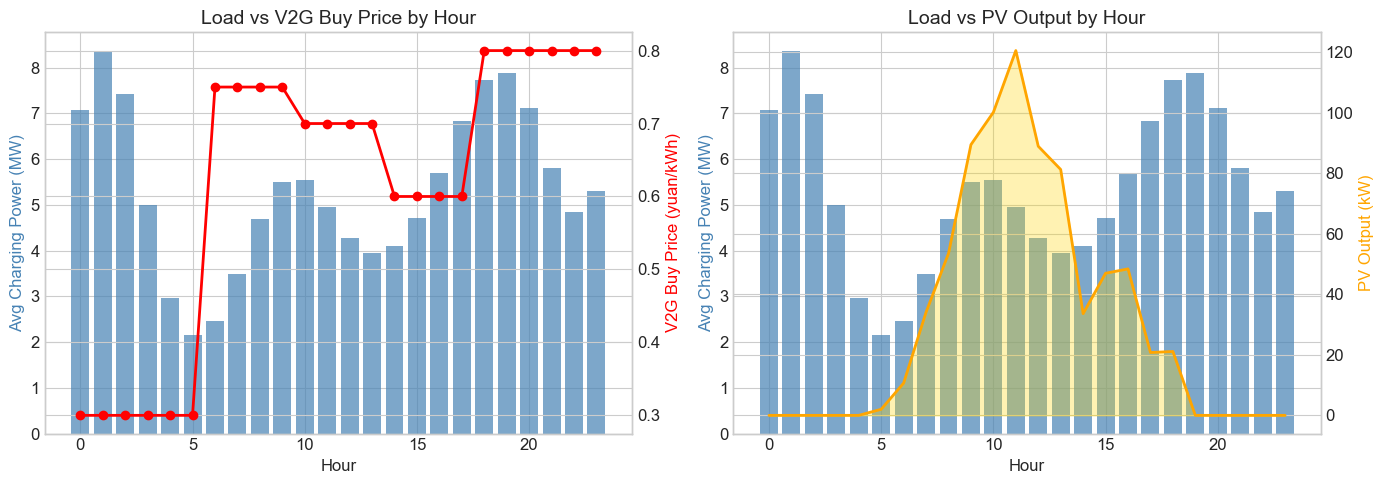

In [46]:
# Visualize price vs load relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# V2G buy price vs load
hourly_stats = train_df.groupby('hour').agg({'V': 'mean', 'v2g_buy_price': 'first', 'pv_output': 'first'})

ax1 = axes[0]
ax1.bar(hourly_stats.index, hourly_stats['V'], alpha=0.7, color='steelblue', label='Load')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Avg Charging Power (MW)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly_stats.index, hourly_stats['v2g_buy_price'], 'r-o', linewidth=2, label='Buy Price')
ax2.set_ylabel('V2G Buy Price (yuan/kWh)', color='red')

axes[0].set_title('Load vs V2G Buy Price by Hour')

# Load vs PV output
ax3 = axes[1]
ax3.bar(hourly_stats.index, hourly_stats['V'], alpha=0.7, color='steelblue')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Avg Charging Power (MW)', color='steelblue')

ax4 = ax3.twinx()
ax4.fill_between(hourly_stats.index, hourly_stats['pv_output'], alpha=0.3, color='gold', label='PV Output')
ax4.plot(hourly_stats.index, hourly_stats['pv_output'], 'orange', linewidth=2)
ax4.set_ylabel('PV Output (kW)', color='orange')

axes[1].set_title('Load vs PV Output by Hour')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_load_vs_external.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Visualization Summary & Key Findings

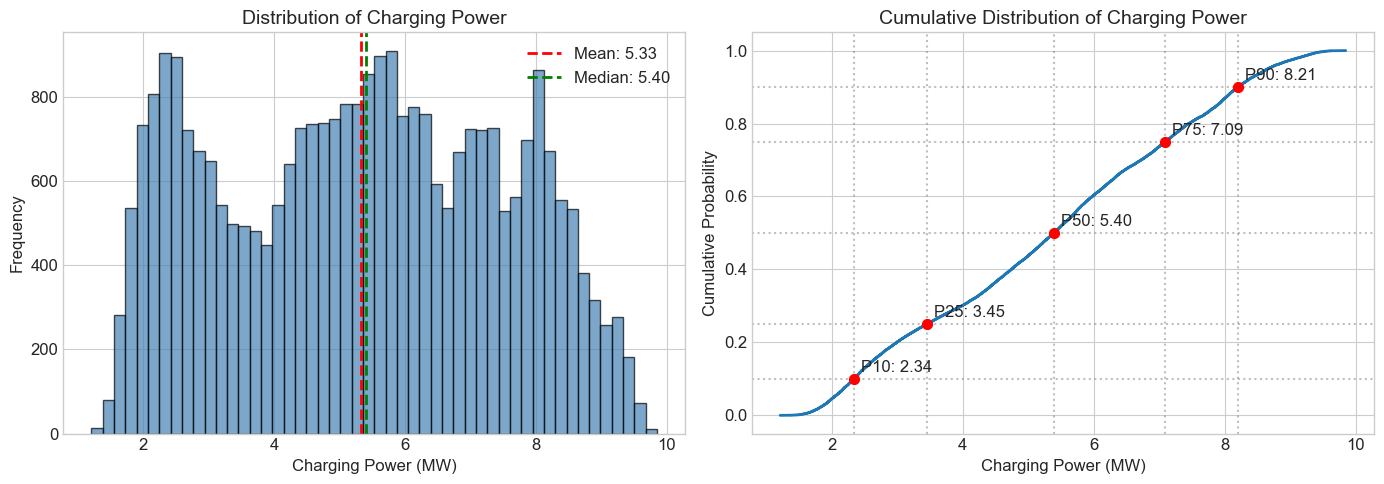

In [47]:
# Distribution of charging power
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['V'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(train_df['V'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_df["V"].mean():.2f}')
axes[0].axvline(train_df['V'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train_df["V"].median():.2f}')
axes[0].set_xlabel('Charging Power (MW)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Charging Power')
axes[0].legend()

# CDF
sorted_v = np.sort(train_df['V'])
cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
axes[1].plot(sorted_v, cdf, linewidth=2)
axes[1].set_xlabel('Charging Power (MW)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Distribution of Charging Power')

# Mark percentiles
for p in [10, 25, 50, 75, 90]:
    val = np.percentile(train_df['V'], p)
    axes[1].axhline(y=p/100, color='gray', linestyle=':', alpha=0.5)
    axes[1].axvline(x=val, color='gray', linestyle=':', alpha=0.5)
    axes[1].scatter([val], [p/100], color='red', s=50, zorder=5)
    axes[1].annotate(f'P{p}: {val:.2f}', (val, p/100), textcoords="offset points", xytext=(5, 5))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Summary statistics
print("=" * 60)
print("EDA SUMMARY & KEY FINDINGS")
print("=" * 60)
print()
print("1. DATA OVERVIEW")
print(f"   - Training period: 2024/1/1 - 2024/10/31 (304 days)")
print(f"   - Total samples: {len(train_df):,}")
print(f"   - Sampling: 15-minute intervals (96 points/day)")
print(f"   - Missing values: {train_df.isnull().sum().sum()}")
print()
print("2. TARGET VARIABLE (V - Charging Power)")
print(f"   - Mean: {train_df['V'].mean():.2f} MW")
print(f"   - Std: {train_df['V'].std():.2f} MW")
print(f"   - Min: {train_df['V'].min():.2f} MW")
print(f"   - Max: {train_df['V'].max():.2f} MW")
print()
print("3. DAILY PATTERN")
peak_hour = hourly_avg['mean'].idxmax()
min_hour = hourly_avg['mean'].idxmin()
print(f"   - Peak hour: {peak_hour:02d}:00 ({hourly_avg.loc[peak_hour, 'mean']:.2f} MW avg)")
print(f"   - Min hour: {min_hour:02d}:00 ({hourly_avg.loc[min_hour, 'mean']:.2f} MW avg)")
print()
print("4. WEEKLY PATTERN")
weekday_mean = train_df[~train_df['is_weekend']]['V'].mean()
weekend_mean = train_df[train_df['is_weekend']]['V'].mean()
print(f"   - Weekday avg: {weekday_mean:.2f} MW")
print(f"   - Weekend avg: {weekend_mean:.2f} MW")
print(f"   - Difference: {((weekend_mean - weekday_mean) / weekday_mean * 100):.1f}%")
print()
print("5. KEY CORRELATIONS WITH TARGET (V)")
for feat in ['AVGV', 'MAXV', 'MINV', 'S']:
    print(f"   - {feat}: {corr_matrix.loc[feat, 'V']:.3f}")
print()
print("6. EXTERNAL DATA AVAILABLE")
print("   - V2G prices: 5 time periods")
print("   - PV output: 96 time slots (typical day)")
print("   - EV user prices: hourly charge/discharge rates")
print("   - Line parameters: 9 line segments")
print()
print("=" * 60)

EDA SUMMARY & KEY FINDINGS

1. DATA OVERVIEW
   - Training period: 2024/1/1 - 2024/10/31 (304 days)
   - Total samples: 29,280
   - Sampling: 15-minute intervals (96 points/day)
   - Missing values: 0

2. TARGET VARIABLE (V - Charging Power)
   - Mean: 5.33 MW
   - Std: 2.13 MW
   - Min: 1.21 MW
   - Max: 9.85 MW

3. DAILY PATTERN
   - Peak hour: 01:00 (8.35 MW avg)
   - Min hour: 05:00 (2.16 MW avg)

4. WEEKLY PATTERN
   - Weekday avg: 4.91 MW
   - Weekend avg: 6.40 MW
   - Difference: 30.3%

5. KEY CORRELATIONS WITH TARGET (V)
   - AVGV: 0.336
   - MAXV: 0.154
   - MINV: 0.320
   - S: 0.651

6. EXTERNAL DATA AVAILABLE
   - V2G prices: 5 time periods
   - PV output: 96 time slots (typical day)
   - EV user prices: hourly charge/discharge rates
   - Line parameters: 9 line segments



---
## 7. Save Processed Data

In [49]:
# Save enhanced training data with time features
output_path = PROJECT_ROOT / 'data' / 'processed' / 'train_with_features.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)

train_df.to_csv(output_path, index=False)
print(f"Saved enhanced training data to: {output_path}")
print(f"Shape: {train_df.shape}")

Saved enhanced training data to: /Users/z/基于多源数据融合的电动汽车充电协同优化挑战/data/processed/train_with_features.csv
Shape: (29280, 24)


In [50]:
print("\nEDA Complete! Generated visualization files:")
print("  - fig_full_timeseries.png")
print("  - fig_sample_week.png")
print("  - fig_daily_pattern.png")
print("  - fig_weekly_pattern.png")
print("  - fig_weekly_heatmap.png")
print("  - fig_monthly_pattern.png")
print("  - fig_correlation_heatmap.png")
print("  - fig_scatter_features.png")
print("  - fig_pv_output.png")
print("  - fig_ev_prices.png")
print("  - fig_load_vs_external.png")
print("  - fig_distribution.png")


EDA Complete! Generated visualization files:
  - fig_full_timeseries.png
  - fig_sample_week.png
  - fig_daily_pattern.png
  - fig_weekly_pattern.png
  - fig_weekly_heatmap.png
  - fig_monthly_pattern.png
  - fig_correlation_heatmap.png
  - fig_scatter_features.png
  - fig_pv_output.png
  - fig_ev_prices.png
  - fig_load_vs_external.png
  - fig_distribution.png


---
## 8. EDA 结论与建模建议

### 8.1 数据质量评估

| 指标 | 状态 | 说明 |
|------|------|------|
| 完整性 | ✅ 优秀 | 29,280条记录无缺失 |
| 连续性 | ✅ 优秀 | 304天×96点完整覆盖 |
| 异常值 | ✅ 正常 | V范围 1.21~9.85 MW 合理 |

---

### 8.2 核心发现

#### 🔴 发现1: 周末负荷高于工作日 (+30.3%)

```
工作日平均: 4.91 MW
周末平均:   6.40 MW
```

**解释**: 电动汽车充电站主要服务于私家车，周末用户充电需求更高。

#### 🔴 发现2: 峰值在凌晨 (01:00)，而非白天

```
峰值: 01:00 (8.35 MW) - 深夜充电高峰
低谷: 05:00 (2.16 MW) - 清晨最低
峰谷差: 6.19 MW (286%)
```

**解释**: 用户利用夜间低谷电价充电，符合V2G场景特征。

#### 🔴 发现3: 极强的自相关性

```
滞后1期 (15分钟): 0.984 (极强)
滞后96期 (1天):   0.758 (强)
```

**建模建议**: 使用历史V值作为特征非常有效，序列模型(LSTM/Transformer)很适合。

---

### 8.3 特征重要性排序

| 特征 | 相关系数 | 重要性 | 说明 |
|------|----------|--------|------|
| `S` | 0.651 | ⭐⭐⭐ | 强特征，需构造 |
| `AVGV` | 0.336 | ⭐⭐ | 有用，但预测时可能不可用 |
| `MINV` | 0.320 | ⭐⭐ | 有用 |
| `AVGS` | 0.308 | ⭐⭐ | 有用 |
| `MAXV` | 0.154 | ⭐ | 弱 |
| `SPAN` | -0.003 | ❌ | 无用，可丢弃 |

**关键结论**:
- 时间特征 (`hour`, `is_weekend`) 虽然不是数值相关，但对周期性建模至关重要

---

### 8.4 外部数据价值

| 数据源 | 与负荷关系 | 建模价值 |
|--------|------------|----------|
| V2G价格 | 非线性 | ⭐⭐ 中等 (价格0.8时负荷最高) |
| PV出力 | 白天补充 | ⭐ 可作为额外特征 |
| EV用户价格 | 待验证 | ⭐ 需进一步分析 |

---

### 8.5 建模策略建议

#### 推荐特征工程方向

**1. 滞后特征 (Lag Features)**
- `V_lag1` (15分钟前), `V_lag96` (1天前), `V_lag672` (1周前)
- 滚动统计: `rolling_mean_4h`, `rolling_std_1d`

**2. 时间特征 (Time Features)**
- `hour` (sin/cos编码), `is_weekend`, `dayofweek`
- `hour × is_weekend` 交互特征

**3. 外部特征 (External Features)**
- `v2g_buy_price`, `v2g_sell_price`, `pv_output`

**4. 模型选择**
- **LightGBM/XGBoost**: 结合滞后特征效果好
- **LSTM/GRU**: 自动捕获时序依赖
- **Transformer**: 长距离依赖建模

---

### 8.6 关键结论汇总表

| 结论 | 影响 |
|------|------|
| 数据质量高 (无缺失) | 可直接建模，无需复杂清洗 |
| 日周期明显 (01:00峰值) | 必须包含hour特征 |
| 周末效应显著 (+30.3%) | 必须区分工作日/周末 |
| 自相关极强 (lag1=0.98) | 滞后特征/时序模型优先 |
| S特征相关高 (0.65) | 需要构造持续时间特征 |
| SPAN特征无用 (-0.003) | 可丢弃 |

In [51]:
# ============================================================
# 数据计算 - EDA结论的数值支撑
# ============================================================

# 1. 数据质量
print(f"样本数: {len(train_df):,}")
print(f"缺失值: {train_df.isnull().sum().sum()}")
print(f"V范围: {train_df['V'].min():.2f} ~ {train_df['V'].max():.2f} MW")

# 2. 周末效应
weekday_mean = train_df[~train_df['is_weekend']]['V'].mean()
weekend_mean = train_df[train_df['is_weekend']]['V'].mean()
print(f"\n周末效应: {(weekend_mean - weekday_mean) / weekday_mean * 100:+.1f}%")

# 3. 自相关性
v_series = train_df['V'].values
lag1 = np.corrcoef(v_series[:-1], v_series[1:])[0,1]
lag96 = np.corrcoef(v_series[:-96], v_series[96:])[0,1]
print(f"滞后1期相关: {lag1:.3f}")
print(f"滞后96期相关: {lag96:.3f}")

# 4. 特征相关性
numeric_cols = ['V', 'AVGV', 'MAXV', 'MINV', 'S', 'AVGS', 'MAXS', 'MINS', 'SPAN']
corr = train_df[numeric_cols].corr()['V'].sort_values(ascending=False)
print(f"\n特征相关性排序:")
for feat in corr.index:
    if feat != 'V':
        print(f"  {feat}: {corr[feat]:.3f}")

样本数: 29,280
缺失值: 0
V范围: 1.21 ~ 9.85 MW

周末效应: +30.3%
滞后1期相关: 0.984
滞后96期相关: 0.758

特征相关性排序:
  S: 0.651
  AVGV: 0.336
  MINV: 0.320
  AVGS: 0.308
  MAXV: 0.154
  MAXS: 0.140
  MINS: 0.128
  SPAN: -0.003
